# SES Completion Count & Median Completion Time Analysis
## Master's and PhD Students — COVID through Post-COVID (2020–2024)

Reproduces the analysis from the PDF summary report.

**Pipeline:** compute counts & medians → visualise → Kruskal-Wallis → Dunn's post-hoc (Bonferroni) → summary table


In [1]:
import importlib
import subprocess
import sys

required = ['scipy', 'scikit_posthocs', 'openpyxl']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    try:
        subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
    except subprocess.CalledProcessError as exc:
        print('Unable to install packages in this environment:', missing)
        print('Please install them manually or use a virtual environment.')
        print('Error:', exc)
else:
    print('All required packages are already installed.')

All required packages are already installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

# Update DATA_PATH if the Excel file is not in the same folder as this notebook
DATA_PATH = 'SESData2020-24.xlsx'

GOLD  = '#C9A030'
ALPHA = 0.05
DEGREE_LABELS = {'MA': "Master's", 'PHD': 'Doctorate (Research)'}
SECTIONS_ORDER = [
    ('MA',  'Spring'), ('MA',  'Summer'), ('MA',  'Fall'),
    ('PHD', 'Spring'), ('PHD', 'Summer'), ('PHD', 'Fall'),
]


In [3]:
df_raw = pd.read_excel(DATA_PATH)

df_raw['Year']   = df_raw['Completed.Term.Descr'].str.extract(r'(\d{4})').astype(int)
df_raw['Season'] = df_raw['Completed.Term.Descr'].str.extract(r'(Spring|Summer|Fall)')
df = df_raw[df_raw['Year'].between(2020, 2024)].copy()

print(f'Records: {len(df)}')
print(f'Degrees: {sorted(df["Degree"].dropna().unique())}')
print(f'Years:   {sorted(df["Year"].unique())}')
print(f'Seasons: {sorted(df["Season"].dropna().unique())}')
df[['Degree','Year','Season','Completed.Time']].head()


Records: 424
Degrees: ['MA', 'PHD']
Years:   [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Seasons: ['Fall', 'Spring', 'Summer']


,Degree,Year,Season,Completed.Time
0,PHD,2020,Spring,3.666667
1,PHD,2020,Spring,5.000000
2,PHD,2020,Spring,5.666667
3,PHD,2020,Spring,4.666667
4,PHD,2020,Spring,4.666667


In [4]:
def get_groups(degree, season):
    mask = (df['Degree'] == degree) & (df['Season'] == season)
    sub  = df[mask].dropna(subset=['Completed.Time'])
    grp  = sub.groupby('Year')['Completed.Time']
    yrs  = sorted(sub['Year'].unique())
    return (
        yrs,
        grp.count().reindex(yrs, fill_value=0),
        grp.median().reindex(yrs).round(2),
        [sub.loc[sub['Year'] == y, 'Completed.Time'].values for y in yrs],
        sub,
    )


def kruskal_wallis(arrays):
    valid = [a for a in arrays if len(a) >= 1]
    if len(valid) < 2:
        return np.nan, np.nan
    return stats.kruskal(*valid)


def dunn_test(sub):
    return sp.posthoc_dunn(
        sub, val_col='Completed.Time', group_col='Year', p_adjust='bonferroni'
    )


def plot_section(years, counts, medians, degree, season):
    label = DEGREE_LABELS[degree]
    fig, axes = plt.subplots(2, 1, figsize=(8, 9))
    fig.subplots_adjust(hspace=0.55)
    panels = [
        (axes[0], counts.values,  'Number of Completions',         True),
        (axes[1], medians.values, 'Median Completed Time (Years)', False),
    ]
    for ax, values, ylabel, is_count in panels:
        suffix = 'number of completions' if is_count else 'median completed time'
        ax.plot(years, values, color=GOLD, marker='o', linewidth=2.5, markersize=9)
        for x, y in zip(years, values):
            lbl = str(int(y)) if is_count else f'{y:.2f}'
            ax.annotate(lbl, (x, y), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=10)
        ax.set_title(f'{label} {suffix} - {season}',
                     fontweight='bold', fontsize=12, pad=12)
        ax.set_xlabel('Term', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xticks(years)
        ax.set_xticklabels([str(y) for y in years])
        ax.set_ylim(bottom=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.show()


def analyse(degree, season):
    """Plot charts, run KW test, and run Dunn's if KW is significant."""
    yrs, counts, medians, arrays, sub = get_groups(degree, season)
    plot_section(yrs, counts, medians, degree, season)
    stat, p = kruskal_wallis(arrays)
    label = DEGREE_LABELS[degree]
    print(f'--- Kruskal-Wallis  ({label} - {season}) ---')
    sig_str = 'SIGNIFICANT' if (not np.isnan(p) and p < ALPHA) else 'not significant'
    print(f'  H = {stat:.6f},  p = {p:.8f}  ->  {sig_str}\n')
    if not np.isnan(p) and p < ALPHA:
        d = dunn_test(sub)
        pairs = [(a, b) for i, a in enumerate(yrs) for b in yrs[i+1:]]
        rows = []
        for a, b in pairs:
            p_bon = d.loc[a, b]
            diff = round(medians.loc[b] - medians.loc[a], 2)
            rows.append({
                'Comparison': f'{a} vs {b}',
                'Delta Median (yrs)': f'{diff:+.2f}',
                'p (Bonferroni)': round(p_bon, 6),
                'Significant': 'Yes' if p_bon < ALPHA else '',
            })
        print('--- Dunn post-hoc (Bonferroni) ---')
        print(pd.DataFrame(rows).to_string(index=False))
        print()
    return yrs, counts, medians, arrays, sub


---
## Master's - Spring

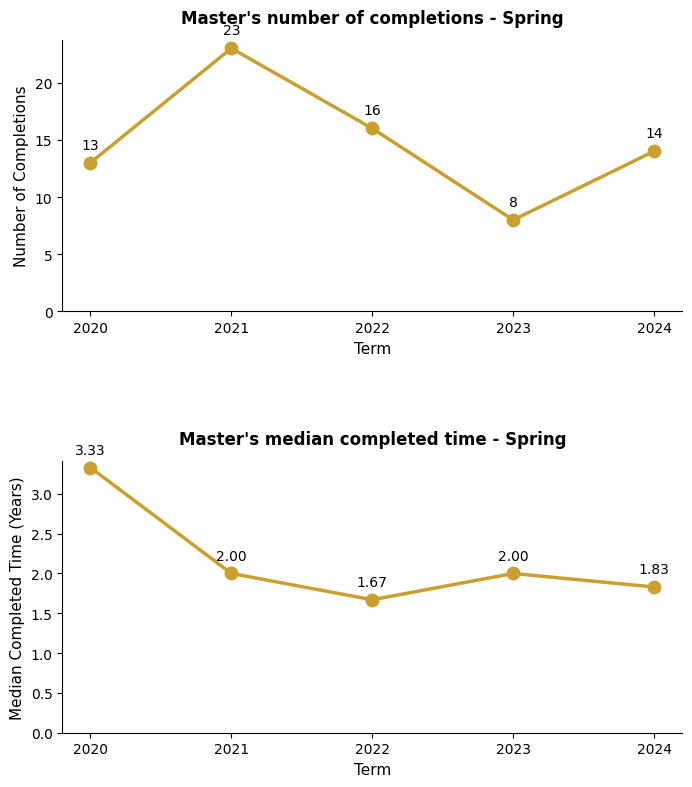

--- Kruskal-Wallis  (Master's - Spring) ---
  H = 7.296865,  p = 0.12100755  ->  not significant



In [5]:
yrs, counts, medians, arrays, sub = analyse('MA', 'Spring')


**Master's — Spring**

While there was an overall decrease in Median Completion Time from 2020 to 2024, no statistically significant differences were found between years. One possible reason is that completion counts were too low to detect a reliable pattern.

**We cannot claim any actual change in Median Completion Time for Master's students graduating in the Spring.**

---
## Master's - Summer

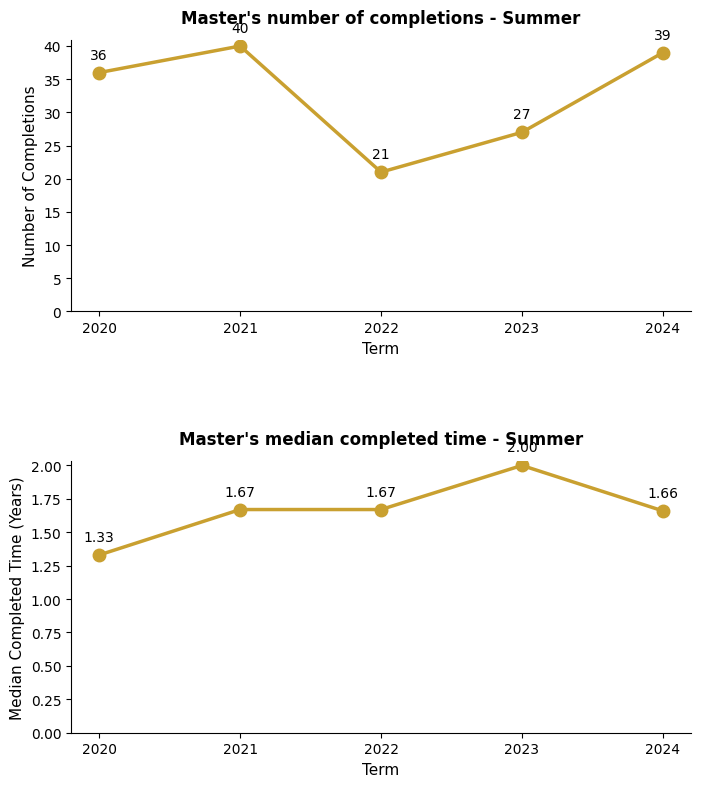

--- Kruskal-Wallis  (Master's - Summer) ---
  H = 27.750917,  p = 0.00001401  ->  SIGNIFICANT

--- Dunn post-hoc (Bonferroni) ---
  Comparison Delta Median (yrs)  p (Bonferroni) Significant
2020 vs 2021              +0.34        0.024892         Yes
2020 vs 2022              +0.34        1.000000            
2020 vs 2023              +0.67        0.000025         Yes
2020 vs 2024              +0.33        1.000000            
2021 vs 2022              +0.00        1.000000            
2021 vs 2023              +0.33        0.428834            
2021 vs 2024              -0.01        0.207118            
2022 vs 2023              +0.33        0.098771            
2022 vs 2024              -0.01        1.000000            
2023 vs 2024              -0.34        0.000425         Yes



In [6]:
yrs, counts, medians, arrays, sub = analyse('MA', 'Summer')


**Master's — Summer**

Statistically significant differences were found between:
- 2020 vs 2021 (+0.34 years)
- 2020 vs 2023 (+0.67 years)
- 2023 vs 2024 (-0.34 years)

**Median Completion Time increased from 2020 to 2023, then decreased from 2023 to 2024 for Master's students graduating in the Summer.**

---
## Master's - Fall

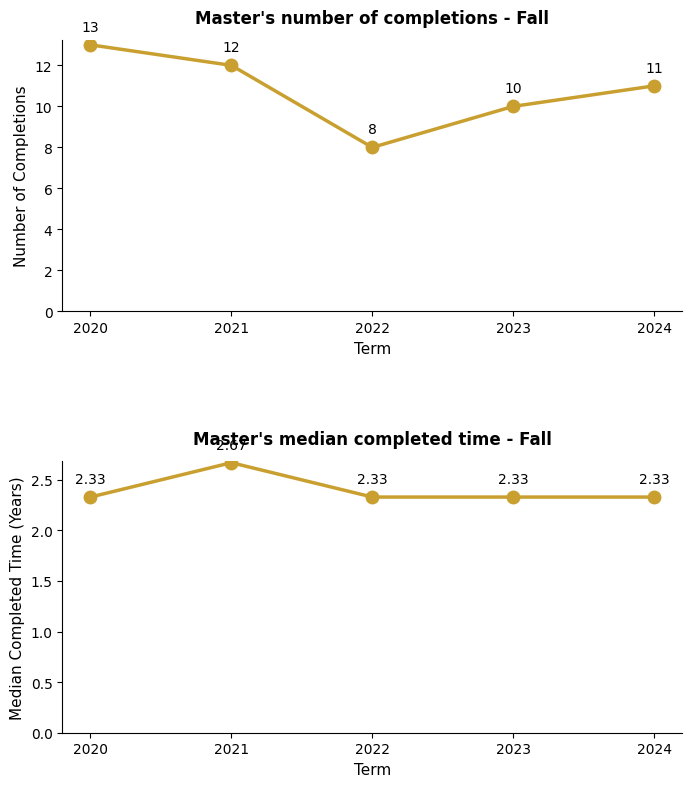

--- Kruskal-Wallis  (Master's - Fall) ---
  H = 1.491660,  p = 0.82811769  ->  not significant



In [7]:
yrs, counts, medians, arrays, sub = analyse('MA', 'Fall')


**Master's — Fall**

Median Completion Time remained relatively stable across all Fall terms (2020-2024). No statistically significant differences were found between years.

**We cannot claim any actual change in Median Completion Time for Master's students graduating in the Fall.**

---
## Doctorate (Research) - Spring

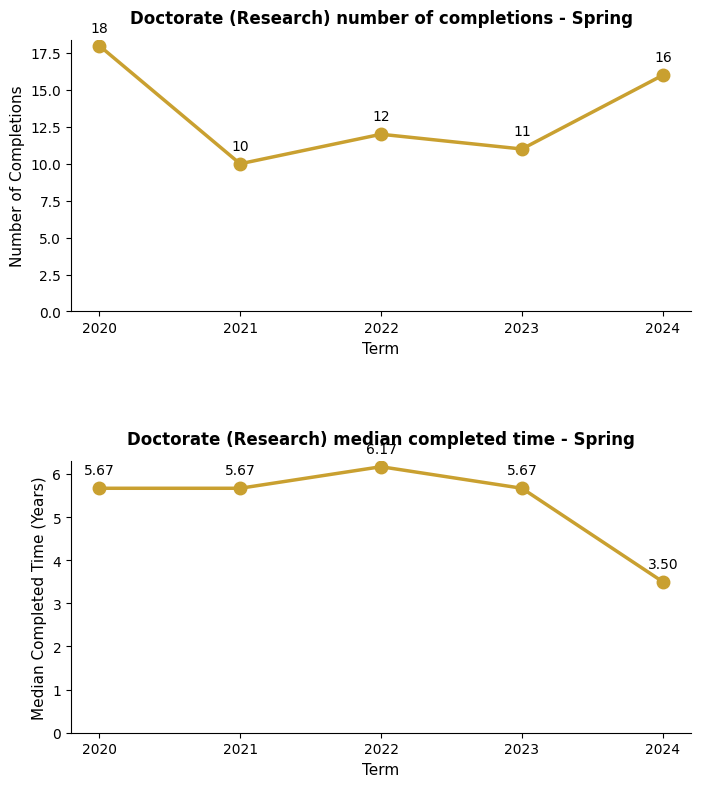

--- Kruskal-Wallis  (Doctorate (Research) - Spring) ---
  H = 8.971927,  p = 0.06180502  ->  not significant



In [8]:
yrs, counts, medians, arrays, sub = analyse('PHD', 'Spring')


**Doctorate (Research) — Spring**

While there was a general decrease in Median Completion Time from 2020 to 2024, no statistically significant differences were found between years.

**We cannot claim any actual change in Median Completion Time for PhD students graduating in the Spring.**

---
## Doctorate (Research) - Summer

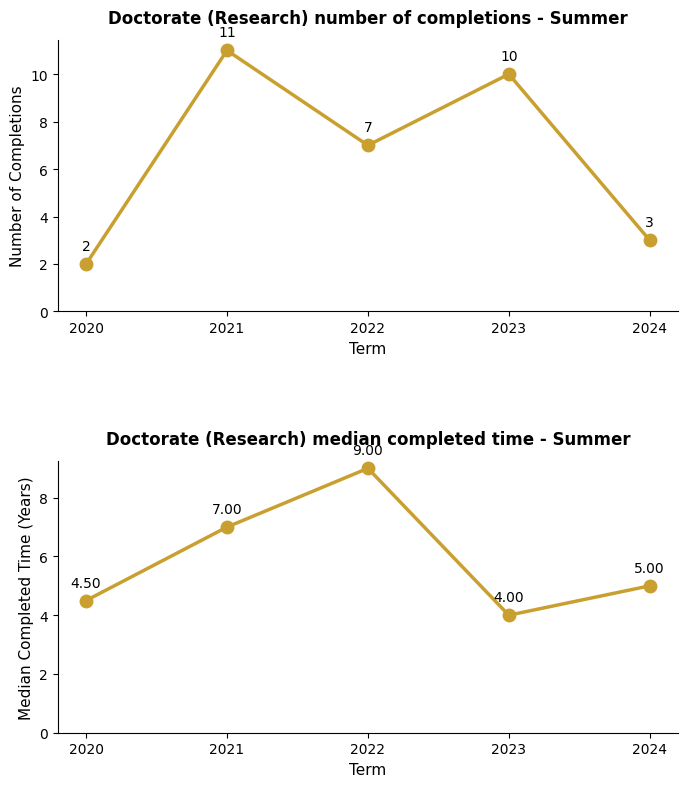

--- Kruskal-Wallis  (Doctorate (Research) - Summer) ---
  H = 11.274061,  p = 0.02365062  ->  SIGNIFICANT

--- Dunn post-hoc (Bonferroni) ---
  Comparison Delta Median (yrs)  p (Bonferroni) Significant
2020 vs 2021              +2.50        1.000000            
2020 vs 2022              +4.50        1.000000            
2020 vs 2023              -0.50        1.000000            
2020 vs 2024              +0.50        1.000000            
2021 vs 2022              +2.00        1.000000            
2021 vs 2023              -3.00        0.083738            
2021 vs 2024              -2.00        1.000000            
2022 vs 2023              -5.00        0.034348         Yes
2022 vs 2024              -4.00        1.000000            
2023 vs 2024              +1.00        1.000000            



In [9]:
yrs, counts, medians, arrays, sub = analyse('PHD', 'Summer')


**Doctorate (Research) — Summer**

A statistically significant difference was found between:
- 2022 vs 2023 (-5.00 years)

**Median Completion Time decreased significantly from 2022 to 2023 for PhD students graduating in the Summer.**

---
## Doctorate (Research) - Fall

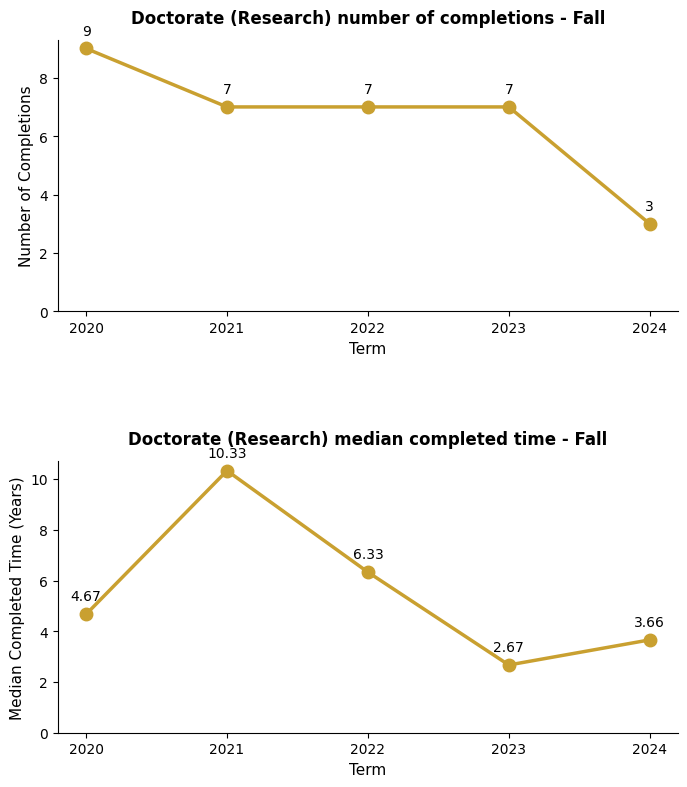

--- Kruskal-Wallis  (Doctorate (Research) - Fall) ---
  H = 9.302165,  p = 0.05397495  ->  not significant



In [10]:
yrs, counts, medians, arrays, sub = analyse('PHD', 'Fall')


**Doctorate (Research) — Fall**

While there were year-to-year differences in Median Completion Time, none were statistically significant.

**We cannot claim any actual change in Median Completion Time for PhD students graduating in the Fall.**

---
## Summary of Significant Differences

In [11]:
rows = []
for degree, season in SECTIONS_ORDER:
    yrs, cnts, meds, arrs, sub = get_groups(degree, season)
    stat, p = kruskal_wallis(arrs)
    sig = not np.isnan(p) and p < ALPHA
    if sig:
        d = dunn_test(sub)
        pairs = [(a, b) for i, a in enumerate(yrs) for b in yrs[i+1:]]
        any_sig = False
        for a, b in pairs:
            p_bon = d.loc[a, b]
            if p_bon < ALPHA:
                diff = round(meds.loc[b] - meds.loc[a], 2)
                rows.append({'Degree': degree, 'Term': season,
                    'Significant Differences?': 'Yes',
                    'Details': f'{a} vs {b}',
                    'Delta Median Completion Time (Years)': diff,
                    'Did median time to graduate change?': 'Yes'})
                any_sig = True
        if not any_sig:
            rows.append({'Degree': degree, 'Term': season,
                'Significant Differences?': 'Yes', 'Details': 'None after Bonferroni',
                'Delta Median Completion Time (Years)': 'N/A',
                'Did median time to graduate change?': 'No'})
    else:
        rows.append({'Degree': degree, 'Term': season,
            'Significant Differences?': 'No', 'Details': 'N/A',
            'Delta Median Completion Time (Years)': 'N/A',
            'Did median time to graduate change?': 'No'})
pd.DataFrame(rows)


,Degree,Term,Significant Differences?,Details,Delta Median Completion Time (Years),Did median time to graduate change?
0,MA,Spring,No,N/A,N/A,No
1,MA,Summer,Yes,2020 vs 2021,0.34,Yes
2,MA,Summer,Yes,2020 vs 2023,0.67,Yes
3,MA,Summer,Yes,2023 vs 2024,-0.34,Yes
4,MA,Fall,No,N/A,N/A,No
5,PHD,Spring,No,N/A,N/A,No
6,PHD,Summer,Yes,2022 vs 2023,-5.0,Yes
7,PHD,Fall,No,N/A,N/A,No


---
## Appendix: Statistical Test Details

In [12]:
# Kruskal-Wallis results
print('=== Kruskal-Wallis Test Results ===')
kw_rows = []
for degree, season in SECTIONS_ORDER:
    _, _, _, arrays, _ = get_groups(degree, season)
    stat, p = kruskal_wallis(arrays)
    kw_rows.append({'Degree': degree, 'Season': season,
        'KW Statistic': round(stat, 6), 'P-Value': f'{p:.6e}',
        'Significant': 'Yes' if (not np.isnan(p) and p < ALPHA) else 'No'})
kw_df = pd.DataFrame(kw_rows)
print(kw_df.to_string(index=False))
print()

# Dunn post-hoc for significant groups
print('=== Dunn Post-hoc (Bonferroni) — Significant Groups Only ===')
for degree, season in SECTIONS_ORDER:
    yrs, _, meds, arrs, sub = get_groups(degree, season)
    stat, p = kruskal_wallis(arrs)
    if not np.isnan(p) and p < ALPHA:
        label = DEGREE_LABELS[degree]
        print(f'--- {label} - {season} ---')
        d = dunn_test(sub)
        pairs = [(a, b) for i, a in enumerate(yrs) for b in yrs[i+1:]]
        for a, b in pairs:
            p_bon = d.loc[a, b]
            diff = round(meds.loc[b] - meds.loc[a], 2)
            flag = ' <- significant' if p_bon < ALPHA else ''
            print(f'  {a} vs {b}: delta={diff:+.2f} yrs, p(Bonferroni)={p_bon:.6f}{flag}')
        print()


=== Kruskal-Wallis Test Results ===
Degree Season  KW Statistic      P-Value Significant
    MA Spring      7.296865 1.210075e-01          No
    MA Summer     27.750917 1.400991e-05         Yes
    MA   Fall      1.491660 8.281177e-01          No
   PHD Spring      8.971927 6.180502e-02          No
   PHD Summer     11.274061 2.365062e-02         Yes
   PHD   Fall      9.302165 5.397495e-02          No

=== Dunn Post-hoc (Bonferroni) — Significant Groups Only ===
--- Master's - Summer ---
  2020 vs 2021: delta=+0.34 yrs, p(Bonferroni)=0.024892 <- significant
  2020 vs 2022: delta=+0.34 yrs, p(Bonferroni)=1.000000
  2020 vs 2023: delta=+0.67 yrs, p(Bonferroni)=0.000025 <- significant
  2020 vs 2024: delta=+0.33 yrs, p(Bonferroni)=1.000000
  2021 vs 2022: delta=+0.00 yrs, p(Bonferroni)=1.000000
  2021 vs 2023: delta=+0.33 yrs, p(Bonferroni)=0.428834
  2021 vs 2024: delta=-0.01 yrs, p(Bonferroni)=0.207118
  2022 vs 2023: delta=+0.33 yrs, p(Bonferroni)=0.098771
  2022 vs 2024: delta=-0.01